# **<p align="center"> Crystal Files </p>**

## <ins> Description </ins>
### Look to understand the crystal data and what are the assumptions and patterns.

<details open>
<summary> <font size="6"> <ins> Key Questions </ins> </font> </summary>

- Is there a difference between the subset pdbs for the crystal data?


</details>

</br>


In [1]:
# Load Key Libraries
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem
import matplotlib.pyplot as plt

from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord, clear_empty

/home/eoo22534/mydir/xaidar/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## Q. Is there a difference between the subset pdbs for the crystal data?

- ### RMSD

In [2]:
# Get the main data directory for crystallographic datasets
cryst_data_dir = rootdir.joinpath("data/ev2a/fragalysis/01-concatDir/crystallographic_files")
cryst_data_dir.exists()

True

#### Strip down hierarchies in pdbs into residues

In [3]:
# reverse for later test
def flatten_structure(pdb: gemmi.Structure, reverse = False):
    if reverse:    result = clear_empty( createPDB( resSpan = flatten_pdb( pdb, "residue")[::-1] ) )
    else:     result = clear_empty( createPDB( resSpan = flatten_pdb( pdb, "residue") ) )
    return result

In [4]:
# Test flatten_structure with one dataset
dataset_path = cryst_data_dir.joinpath( "0501")
ref_prot = loadPDB( dataset_path.joinpath( f"A{dataset_path.name}a.pdb"))
get_pdb_stats( ref_prot)
get_pdb_stats( flatten_structure( ref_prot) )


####################
Number of models: 1
Number of chains in 1st Model: 4

Chain ID: A
	Number of Residues: 143
	Unique List of Non-A.A.: {'LIG', 'ZN'}
	Contains A.A.
Chain ID: B
	Number of Residues: 141
	Unique List of Non-A.A.: {'ZN'}
	Contains A.A.
Chain ID: C
	Number of Residues: 3
	Unique List of Non-A.A.: {'DMS'}
Chain ID: H
	Number of Residues: 416
	Unique List of Non-A.A.: {'HOH'}

####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 703
	Unique List of Non-A.A.: {'HOH', 'DMS', 'LIG', 'ZN'}
	Contains A.A.


In [5]:
# Calculate RMSD
from xaidar.data.molecModels import structAlign
rmsd_per_dataset = []
dataset_labels = []
manysubsetDatasets = []
subsetid = set()    # Check assumption that the subset labels are always a and b

for dataset_path in cryst_data_dir.iterdir():
    num_subsets = len( list(dataset_path.glob("*.pdb") ) )
    if  num_subsets== 2:
        for subset in dataset_path.glob("*.pdb"):
            subsetid.add(subset.name[-5:-4])
        ref_prot =  flatten_structure( loadPDB(
            dataset_path.joinpath( f"A{dataset_path.name}a.pdb")) )
        mob_prot = flatten_structure(  loadPDB(
            dataset_path.joinpath( f"A{dataset_path.name}b.pdb")) , reverse = False)
        align = structAlign( ref_prot, mob_prot).calc_rmsd().rmsd
        rmsd_per_dataset.append(align)
        dataset_labels.append( dataset_path.name)
    elif num_subsets > 2: manysubsetDatasets.append( dataset_path.name)
    else: continue

In [6]:
print( "Check RMSD Content", set(rmsd_per_dataset ))
print( "Check Number of datasets with two subsets", len(dataset_labels))
print( "Check Number of datasets with more than two subsets", len(manysubsetDatasets))
print("Check assumption that the subset labels are always a and b:\n\t",subsetid)

Check RMSD Content {0.0}
Check Number of datasets with two subsets 123
Check Number of datasets with more than two subsets 5
Check assumption that the subset labels are always a and b:
	 {'a', 'b'}


In [7]:
print(len(manysubsetDatasets))

5


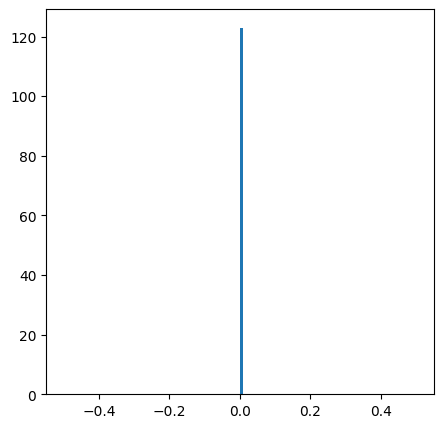

In [8]:
plt.figure( figsize = (5,5))
plt.hist( rmsd_per_dataset, bins = 100)
plt.show()

### - Check if analysis is right by creating bad rmsds

In [10]:
# Calculate RMSD
from xaidar.data.molecModels import structAlign
rmsd_per_dataset = []
dataset_labels = []
manysubsetDatasets = []
subsetid = set()    # Check assumption that the subset labels are always a and b

for dataset_path in cryst_data_dir.iterdir():
    num_subsets = len( list(dataset_path.glob("*.pdb") ) )
    if  num_subsets== 2:
        for subset in dataset_path.glob("*.pdb"):
            subsetid.add(subset.name[-5:-4])
        ref_prot =  flatten_structure( loadPDB(
            dataset_path.joinpath( f"A{dataset_path.name}a.pdb")) )
        mob_prot = flatten_structure(  loadPDB(
            dataset_path.joinpath( f"A{dataset_path.name}b.pdb")) , reverse = True)
        align = structAlign( ref_prot, mob_prot).calc_rmsd().rmsd
        rmsd_per_dataset.append(align)
        dataset_labels.append( dataset_path.name)
    elif num_subsets > 2: manysubsetDatasets.append( dataset_path.name)
    else: continue

In [11]:
print( "Check RMSD Content", set(rmsd_per_dataset ))
print( "Check Number of datasets with two subsets", len(dataset_labels))
print( "Check Number of datasets with more than two subsets", len(manysubsetDatasets))
print("Check assumption that the subset labels are always a and b:\n\t",subsetid)

Check RMSD Content {32.28182093096744, 19.582032157096073, 19.64092427397882, 19.55063428976746, 22.59508660718796, 23.62665557271541, 24.459622462670872, 24.585528051415313, 26.336973195196656, 24.054037775490436, 24.185041386690088, 24.961049901656423, 30.4271139336093, 31.32890343380347, 32.18113212352903, 33.571191301884284, 33.113230821152044, 32.941467404808336, 32.7564013321912, 31.20046935781488, 32.12200930153199, 33.92571773063114, 31.939916241820793, 32.7705283190519, 33.49741473659265, 34.27983490347169, 35.31650266185951, 33.80155665147309, 31.234124096336146, 33.45054834238669, 33.01231781432022, 30.988624350544484, 32.322083023993066, 33.003704397304205, 32.59098292039029, 33.48686320855371, 32.47289038121098, 19.025964782055887, 20.23685451869462, 32.24202120562623, 32.88394565125569, 33.677974682101784, 23.263212020542007, 23.635871271924344, 25.5403211899312, 30.931783403251423, 30.350182162578456, 30.36054051136371, 30.94109208902036, 32.51064541720796, 31.0227433058

In [12]:
print(len(manysubsetDatasets))

5


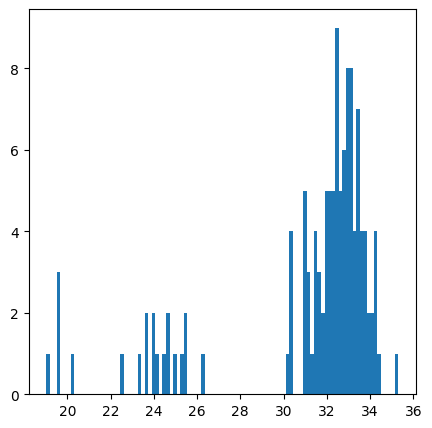

In [13]:
plt.figure( figsize = (5,5))
plt.hist( rmsd_per_dataset, bins = 100)
plt.show()

## A. No, the rmsds are always zero, which would only happen if the files were exactly the same.

---

## Q. Are the ligand residue number, chain label, and residue name, the same for within a subset and between subsets in a crystallographic dataset?

In [ ]:
# Test flatten_structure with one dataset
dataset_path = cryst_data_dir.joinpath( "0501")
ref_prot = loadPDB( dataset_path.joinpath( f"A{dataset_path.name}a.pdb"))
get_pdb_stats( ref_prot)

# get_pdb_stats( flatten_structure( ref_prot) )